# FX Transaction Cost Analysis (TCA)

A transaction-cost analysis framework for FX order execution. It compares execution algorithms (immediate, TWAP, front-loaded) on real intraday price data, decomposes execution cost into spread / market-impact / timing components, and shows how cost depends on order size.

**What is real and what is modelled**
- *Real:* intraday FX prices, pulled from Yahoo Finance.
- *Modelled:* parent orders are hypothetical, and execution cost uses a stylised model (a fixed half-spread plus a square-root market-impact term, consistent with the market-impact literature). Desk TCA on a live platform would use actual fills and a venue-calibrated impact model.

The deliverable is the framework and the comparative analysis, not a P&L claim.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---
PAIRS = {
    "EURUSD=X": "EUR/USD",
    "GBPUSD=X": "GBP/USD",
    "USDJPY=X": "USD/JPY",
}
PERIOD          = "730d"        # ~2 years of intraday history
INTERVAL        = "1h"          # hourly bars
WINDOW_BARS     = 8             # work each parent order over 8 hourly bars
HALF_SPREAD_BPS = {"EUR/USD": 0.4, "GBP/USD": 0.8, "USD/JPY": 0.5}
IMPACT_COEF     = 1.5           # square-root market-impact coefficient (bps)
ORDER_SIZES     = {"Small": 1.0, "Medium": 4.0, "Large": 16.0}
ALGOS           = ["Immediate", "TWAP", "Front-loaded"]

## 1. Data

Download ~2 years of hourly FX prices for three major pairs. FX has no consolidated traded volume, so the close price is treated as the mid.

In [2]:
import yfinance as yf

raw = yf.download(list(PAIRS), period=PERIOD, interval=INTERVAL, progress=False)["Close"]
raw = raw.rename(columns=PAIRS).ffill().dropna()
fx = {name: raw[name] for name in PAIRS.values()}

print(f"Loaded {len(raw)} hourly bars, {raw.index[0]} to {raw.index[-1]}")
raw.tail()

/var/folders/hm/7tgrvf1s2cs82jf4cs2yjs400000gn/T/ipykernel_2436/2223514659.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(list(PAIRS), period=PERIOD, interval=INTERVAL, progress=False)["Close"]


Loaded 17248 hourly bars, 2023-08-09 23:00:00+00:00 to 2026-05-27 10:00:00+00:00


Ticker,EUR/USD,GBP/USD,USD/JPY
Datetime,,,
2026-05-27 06:00:00+00:00,1.164958,1.345261,159.350006
2026-05-27 07:00:00+00:00,1.164415,1.344339,159.350998
2026-05-27 08:00:00+00:00,1.164822,1.344719,159.393997
2026-05-27 09:00:00+00:00,1.164822,1.344701,159.358994
2026-05-27 10:00:00+00:00,1.164144,1.344140,159.376999


## 2. Execution algorithms

Each parent order is worked over `WINDOW_BARS` hourly slices. The three algorithms differ only in how the order is spread across those slices.

In [3]:
def algo_weights(algo, n):
    """Child-order weights across n bars for a given execution algorithm."""
    if algo == "Immediate":
        w = np.zeros(n); w[0] = 1.0
    elif algo == "TWAP":
        w = np.ones(n) / n
    elif algo == "Front-loaded":
        w = np.linspace(n, 1, n)            # linearly decreasing schedule
        w = w / w.sum()
    else:
        raise ValueError(f"Unknown algo: {algo}")
    return w

# the three execution schedules side by side
pd.DataFrame({a: algo_weights(a, WINDOW_BARS) for a in ALGOS}).round(3)

,Immediate,TWAP,Front-loaded
0,1.0,0.125,0.222
1,0.0,0.125,0.194
2,0.0,0.125,0.167
3,0.0,0.125,0.139
4,0.0,0.125,0.111
5,0.0,0.125,0.083
6,0.0,0.125,0.056
7,0.0,0.125,0.028


## 3. Cost model

Each child order fills at the prevailing mid, worsened by a fixed **half-spread** and a **square-root market-impact** term — larger child orders move the market more.

Implementation shortfall is the gap between the size-weighted average execution price and the arrival price, in basis points. It decomposes cleanly into **spread + impact + timing** cost.

In [4]:
def simulate_execution(mids, weights, half_spread_bps, order_size, side=1):
    """Work one parent order across a window of mid prices.
    Returns implementation shortfall (bps) and its decomposition."""
    arrival = mids[0]
    child_size = weights * order_size

    # square-root market impact: larger child orders move the market more
    impact_bps = IMPACT_COEF * np.sqrt(child_size)

    # each child fills at the prevailing mid, worsened by half-spread + impact
    fill_price = mids * (1 + side * (half_spread_bps + impact_bps) / 1e4)
    avg_exec = float(np.sum(weights * fill_price))

    is_bps = side * (avg_exec - arrival) / arrival * 1e4
    spread_cost = half_spread_bps
    impact_cost = float(np.sum(weights * impact_bps))
    timing_cost = is_bps - spread_cost - impact_cost
    return {"IS": is_bps, "Spread": spread_cost,
            "Impact": impact_cost, "Timing": timing_cost}


def run_tca(mid_series, half_spread_bps):
    """Run every algorithm / order size over every tradable window."""
    records = []
    for day, bars in mid_series.groupby(mid_series.index.date):
        if len(bars) < WINDOW_BARS:
            continue
        window = bars.iloc[:WINDOW_BARS].to_numpy()
        for algo in ALGOS:
            weights = algo_weights(algo, WINDOW_BARS)
            for size_label, size in ORDER_SIZES.items():
                res = simulate_execution(window, weights, half_spread_bps, size)
                records.append({"day": day, "algo": algo,
                                "size": size_label, **res})
    return pd.DataFrame(records)

## 4. Run the analysis

Simulate every algorithm and order size over every tradable window, across all three pairs.

In [5]:
all_results = []
for pair, mids in fx.items():
    df = run_tca(mids, HALF_SPREAD_BPS[pair])
    df["pair"] = pair
    all_results.append(df)
results = pd.concat(all_results, ignore_index=True)

print(f"Analysed {results['day'].nunique()} trading days across {len(fx)} pairs "
      f"-> {len(results):,} simulated executions.")

Analysed 727 trading days across 3 pairs -> 19,629 simulated executions.


## 5. Results

**Average implementation shortfall** is the headline cost. **Execution risk** is the standard deviation of shortfall — how uncertain that cost is.

In [6]:
pivot_is = results.pivot_table(values="IS", index="algo",
        columns="size", aggfunc="mean")[list(ORDER_SIZES)].loc[ALGOS]
pivot_risk = results.pivot_table(values="IS", index="algo",
        columns="size", aggfunc="std")[list(ORDER_SIZES)].loc[ALGOS]

print("Average implementation shortfall (bps) - lower is better:")
print(pivot_is.round(2).to_string())
print("\nExecution risk - std of implementation shortfall (bps):")
print(pivot_risk.round(2).to_string())

Average implementation shortfall (bps) - lower is better:
size          Small  Medium  Large
algo                              
Immediate      2.07    3.57   6.57
TWAP           0.98    1.51   2.57
Front-loaded   1.05    1.63   2.80

Execution risk - std of implementation shortfall (bps):
size          Small  Medium  Large
algo                              
Immediate      0.17    0.17   0.17
TWAP          11.85   11.85  11.85
Front-loaded   9.04    9.04   9.05


## 6. Cost decomposition

Breaking the cost of a medium order into its three drivers shows *why* each algorithm costs what it does.

In [7]:
decomp = (results[results["size"] == "Medium"]
          .groupby("algo")[["Spread", "Impact", "Timing"]].mean().loc[ALGOS])
print("Cost decomposition for a medium order (bps):")
print(decomp.round(2).to_string())

Cost decomposition for a medium order (bps):
              Spread  Impact  Timing
algo                                
Immediate       0.57    3.00    0.00
TWAP            0.57    1.06   -0.12
Front-loaded    0.57    1.17   -0.10


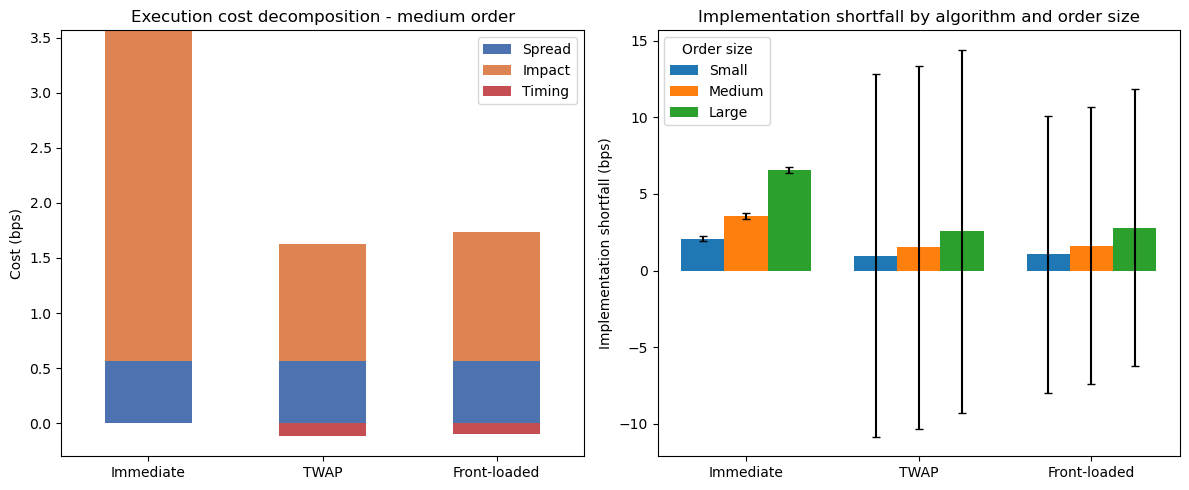

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

decomp.plot(kind="bar", stacked=True, ax=ax[0],
            color=["#4c72b0", "#dd8452", "#c44e52"])
ax[0].set_title("Execution cost decomposition - medium order")
ax[0].set_ylabel("Cost (bps)"); ax[0].set_xlabel("")
ax[0].tick_params(axis="x", rotation=0); ax[0].legend(title=None)

x = np.arange(len(ALGOS)); width = 0.25
for i, size_label in enumerate(ORDER_SIZES):
    ax[1].bar(x + i * width, pivot_is[size_label], width,
              yerr=pivot_risk[size_label], capsize=3, label=size_label)
ax[1].set_xticks(x + width); ax[1].set_xticklabels(ALGOS)
ax[1].set_title("Implementation shortfall by algorithm and order size")
ax[1].set_ylabel("Implementation shortfall (bps)")
ax[1].legend(title="Order size")

fig.tight_layout()
fig.savefig("tca_results.png", dpi=120)
plt.show()

## 7. Reading the results

Faster execution removes exposure to price drift but pays more market impact; slicing reduces impact but increases timing risk. The best algorithm depends on order size — small orders can be executed immediately at low cost, while large orders benefit from being worked over time.

**Limitations**
- No real fills or limit-order-book data; the impact coefficient is not calibrated to a specific venue.
- FX has no consolidated traded volume, so a VWAP benchmark is not used; arrival price is the benchmark.
- A natural extension is to split results by volatility regime, since timing cost should rise when markets move faster.